## 딥러닝
딥러닝이란?
- 인간의 신경망을 모방하여 학습하고 예측하는 기술 - 인공신경망
- 머신러닝에 비해서 다양한 상황이나 유연한 사고가 가능하도록 설계가 된 기술
- 인간의 뉴런을 모방하여 사용한 기술 (뉴런 - 선형모델 사용)
- 대량의 데이터에서 복잫반 패턴이나 규칙등을 찾아내는 능력이 뛰어난 기술이다.
- 병력적 다층구조로 이루어져 있다.
- 주로 컴퓨터 비전이나 음성처리, 자연어 처리등에 많이 사용이 되고 있다.

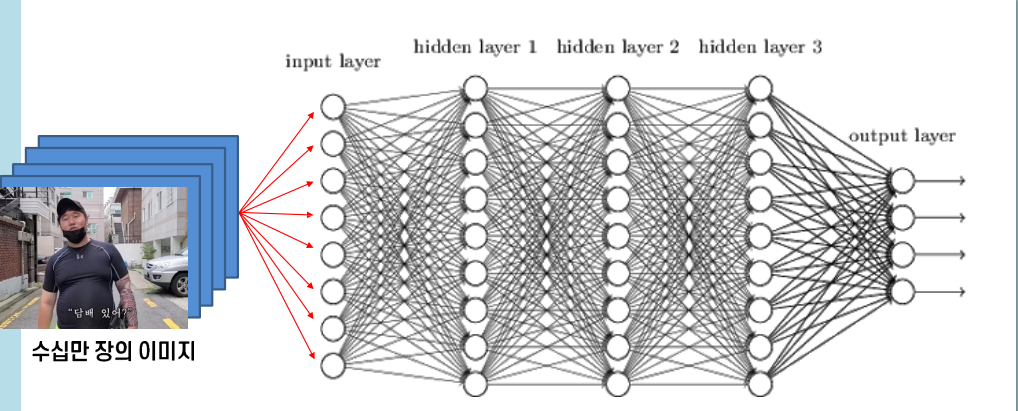

### 머신러닝과 딥러닝의 차이
- 머신러닝
  - 모델을 불로오는 작업 -> 모델학습 -> 예측진행 -> 모델 평가
  - 완제품 로봇을 가져와 색변형 또는 자세변형정도의 간단한 변형을 진행하는 방법 (비유)
- 딥러닝
  - 모델을 직접 설계하여 학습을 진행 후 예측하여 평가가 안좋으면 다시 학습을 진행하는 방법을 사용
  - 설계도를 만들어 부품을 직접 조립하여 로봇에 대해 만들어 원하는 모양을 가진 로봇을 만드는 방법(비유)

### 데이터를 활용하여 머신러닝과 딥러닝 모델을 사용하여 사용법에 대해 어떤 차이점이 있는지 확인하자

### 데이터 가져오기 (학생 성적 데이터)

In [8]:
# 데이터를 다루기 위한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# 데이터 불러오기 (.csv파일)
data = pd.read_csv('./data/student-mat.csv', delimiter= ';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
# 불러온 데이터의 정보 확인
data.info()

# 데이터는 총 395개로 이루어져 있다.
# 컬럼은 33개의 컬럼이 있으며 결측치는 존재하지 않는다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15 ~ 30분,  3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2 ~ 5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |

### 목표
- 데이터를 활용하여 성적을 예측하는 모델을 만들어보기
- 성적 점수를 예측하기 때문에 지도학습의 회귀모델 사용해보기

### 인공지능 7단계
1. 문제정의
2. 데이터 수집
3. 데이터 전처리
4. EDA(탐색적 데이터분석)
5. 모델 선택 및 하이퍼 파라미터 튜닝
6. 모델 학습
7. 모델 평가

In [11]:
# 우리가 모델을 사용할 때 전처리나 분석을 진행해야 하지만 성능을 높이기 위한 것이 아니라
# 모델의 사용에 대해 어떤 차이점이 있는지를 보기 위한 것이기 때문에 전처리나 분석은 스킵
# 데이터를 사용하기 위해 데이터 분리만 진행
# studytime / health 컬럼을 사용하여 성적을 예측
# 문제 데이터 : studytime, health 사용
X = data[['studytime', 'health']]
# 정답 데이터 : 최종성적(G3)
y = data['G3']

In [12]:
# train데이터와 test데이터로 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 8)

In [13]:
# 데이터를 분리했을 때 반드시 shape를 찍어서 형태를 확인
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# 1. 문제와 정답의 개수가 같은지 확인
# 2. 훈련용, 테스트용 입력 특성(컬럼)의 개수가 같은지 확인

(316, 2)
(316,)
(79, 2)
(79,)


### 머신러닝 모델을 학습해보기 (회귀 모델 사용)
- LinearRegression을 사용하여 성적 예측 모델 학습

In [14]:
# 머신러닝 도구 불러오기
from sklearn.linear_model import LinearRegression # 선형모델 도구

# 모델 객체 생성
linear_model = LinearRegression()

# 모델 학습
linear_model.fit(X_train, y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LinearRegression()

In [15]:
# 모델의 성능을 확인하기 위해 오차값 확인
# 회귀에서 오차를 구하는 방법 : MSE를 많이 사용한다.
# MSE확인도구 불러오기
from sklearn.metrics import mean_squared_error

# 테스트 데이터 예측 진행
pre = linear_model.predict(X_test)
# 실제값(정답값)과 예측값을 비교하여 mse 구하기
mse = mean_squared_error(y_test, pre)
mse

22.135811722520756

In [16]:
# 모델 평가 진행 (R^2 score)
linear_model.score(X_test, y_test)

0.006289554607463277

### 딥러닝 모델 사용해보기
- Tensorflow에 들어있는 keras를 활용하여 딥러닝 모델 구축 진행
  - 신경망 구조 설계
  - 학습 방법 및 평가방법 설정
  - 학습진행

### 딥러닝 신경망 설계를 진행할 때 구축 방법
1. 빼대생성 : 신경망을 구축할 때 여러개의 층이 올 수 있도록 뼈대를 생성해줘야 한다.
2. 입력측 : 데이터가 모델에 들어올 수 있도록 데이터를 입력받는 층
3. 중간층(은닉층) : 실제 학습이 일어나는 층 (퍼셉트론을 활용하여 최적의 결과를 낼 수 있도록 학습을 진행하는 층)
4. 출력층 : 학습한 결과를 가지고 예측값을 출력하는 층

In [17]:
# 신경망 설계를 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense

# Tensorflow안에 있는 keras를 활용하여 딥러닝의 여러가지 도구를 사용할 수 있다.1
# Sequential : 뼈대를 생성할 때 사용하는 도구
# inputLayer : 입력층을 쌓는 도구 중 하나
# Dense : 중간층(은닉층)과 출력층을 쌓을 때 사용하는 도구

In [18]:
# 신경망 구축

# 1. 뼈대 생성
deep_model = Sequential()

# 2. 입력층 쌓기 - InputLayer를 사용
# 데이터에 대해서 어떤 형태의 데이터가 들어올지 설정을 해줘야 한다.
# 데이터의 특성의 개수를 알려줘야 입력층을 데이터에 맞게 쌓을 수 있음
# 사용할 데이터 : 2개의 컬럼(요소)를 가진 1차원 데이터를 사용
deep_model.add(InputLayer(shape = (2,)))

# 3. 중간층(은닉층 쌓기) - Dense를 사용 (내가 원하는 만큼 층을 쌓을 수 있음)
deep_model.add(Dense(units = 200, activation = 'sigmoid'))
deep_model.add(Dense(units = 200, activation = 'sigmoid'))
# units : 퍼셉트론의 개수(뉴런의 개수를 지정) : 많으면 다양한 상황을 고려할 수 있기 때문에
# 성능이 올라갈 가능성이 높지만 많을 경우에는 학습속도가 느려진다. (짝수로 설정)
# activation : 활성화 함수 -> 사람처럼 생각하고 판단할 수 있도록 설정하는 기능

# 4. 출력층 쌓기 - Dense 사용
# 목적에 따라서 형태가 정해져있다.
# 회귀를 목적으로 사용할 때     : units = 1 / activation = 'linear'
# 이진분류를 목적으로 사용할 때 : units = 1 / activation = 'sigmoid'
# 다중분류를 목적으로 사여할 때 : units = 클래스의개수(정답의 종류)만큼 / activation = 'softmax'
deep_model.add(Dense(units = 1, activation = 'linear'))

In [19]:
# 학습방법 및 평가방법 설정
# model.compile : 학습방법 및 평가방법을 설정하는 기능
# loss : 오차를 계산하는 방법 설정
# optimizer - 최적화 함수 : 오차를 줄여나가는 방법을 설정하는 기능
# metrics : 평가지표를 설정하는 방
deep_model.compile(
    loss = 'mean_squared_error',
    optimizer = 'SGD',
    metrics = ['mse'] # r2_score 사용가능
)

In [20]:
# 학습진행
# 학습에 필요한 요소
# 1. 데이터 : X_train, y_train
# 2. epochs : 학습횟수 설정
# 3. validation_split : 검증용 데이터 사용 (교차검증 기법과 유사하게 검증용 데이터를 활용하는 방법)
# 4. callbacks : 학습에 적용되는 여러가지 설정 (얼리스탑핑, 모델 저장 등)
deep_model.fit(
    X_train, y_train,
    epochs = 50,
    validation_split = 0.2 # 검증용 데이터의 크기 설정
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 37.0539 - mse: 37.0539 - val_loss: 25.4072 - val_mse: 25.4072
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21.1087 - mse: 21.1087 - val_loss: 25.5038 - val_mse: 25.5038
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.8633 - mse: 19.8633 - val_loss: 24.0546 - val_mse: 24.0546
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.2418 - mse: 20.2418 - val_loss: 24.6982 - val_mse: 24.6982
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.3723 - mse: 20.3723 - val_loss: 25.4989 - val_mse: 25.4989
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.4210 - mse: 20.4210 - val_loss: 27.6510 - val_mse: 27.6510
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.0100 - mse: 21.0100 - val_loss: 27.2015 - val_mse: 27.2015
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.0453 - mse: 22.0453 - val_loss: 26.4004 - val_mse: 26.4004
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

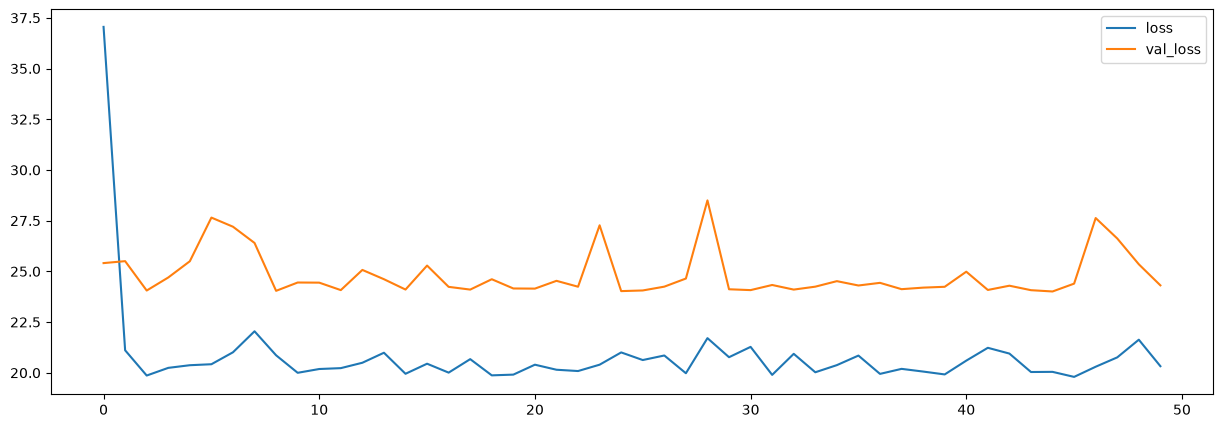

In [21]:
# 결과 시각화 진행
plt.figure(figsize = (15,5))
plt.plot(deep_model.history.history['loss'], label = 'loss')
plt.plot(deep_model.history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

### 결과정리
- 실제 성능은 머신러닝과 크게 차이 없이 별로 좋지 않은 성능을 보임
- 실제 사용한 데이터가 너무 적기 때문에 딥러닝 모델을 사용했다고 해서 성능이 올라가진 않는다.
- 딥러닝은 복잡하고 대용량의 데이터에서 효과적인 기술이기 때문에 머신러닝과 비교했을 때 무조건 성능이 좋은것은 아니다.
- 사용하는 컬럼을 늘려서 성능을 높여보자

### 입력특성을 늘려서 신경망 설계를 진행해보기
- studytime
- health
- freetime
- G1
- G2

In [22]:
X = data[['studytime', 'health', 'freetime', 'G1', 'G2']]
y = data['G3']

In [23]:
# 데이터 분할 진행 (훈련용 데이터, 테스트용 데이터)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 8)

In [24]:
# 데이터 크기 확인
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# 문제데이터와 정답데이터의 개수가 같은지 확인
# 훈련용데이터와 테스트용데이터의 입력특성이 같은지 확인

(316, 5)
(79, 5)
(316,)
(79,)


In [25]:
# 신경망 설계 진행

# 뼈대 생성
model2 = Sequential()

# 입력층 쌓기
model2.add(InputLayer(shape = (5,))) # 5개의 컬럼을 가진 1차원 데이터 사용

# 중간층 쌓기
model2.add(Dense(units = 200, activation = 'sigmoid'))
model2.add(Dense(units = 200, activation = 'sigmoid'))

# 출력층 쌓기
model2.add(Dense(units = 1, activation = 'linear'))

In [26]:
# 학습방법 및 평가방법 설정
model2.compile(
    loss = 'mean_squared_error',
    optimizer = 'SGD',
    metrics = ['r2_score']
)

In [27]:
# 학습
model2.fit(
    X_train, y_train,
    epochs = 50,
    validation_split = 0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 35.7839 - r2_score: -0.8192 - val_loss: 22.3456 - val_r2_score: 0.0713
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19.2729 - r2_score: 0.0202 - val_loss: 24.8729 - val_r2_score: -0.0337
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.6673 - r2_score: 0.1018 - val_loss: 22.3103 - val_r2_score: 0.0728
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.0617 - r2_score: 0.1326 - val_loss: 19.3710 - val_r2_score: 0.1949
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.4724 - r2_score: 0.1626 - val_loss: 19.2260 - val_r2_score: 0.2010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.0879 - r2_score: 0.2838 - val_loss: 16.9569 - val_r2_score: 0.2953
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.7924 - r2_score: 0.3497 - val_loss: 15.0804 - val_r2_score: 0.3733
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 12.9995 - r2_score: 0.3391 - val_loss: 13.9748 - val_r2_s

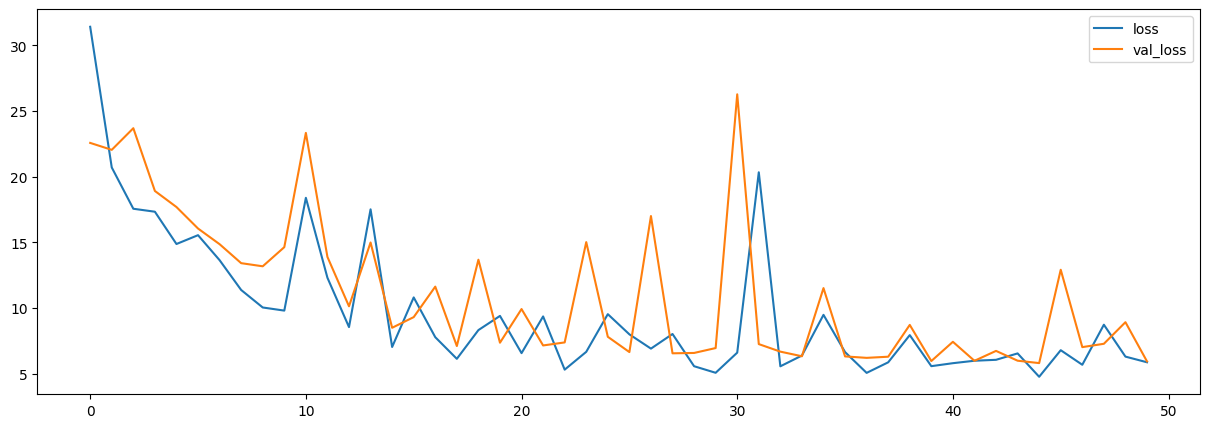

In [ ]:
# 결과 시각화 (오차확인)
plt.figure(figsize = (15,5))
plt.plot(model2.history.history['loss'], label = 'loss')
plt.plot(model2.history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

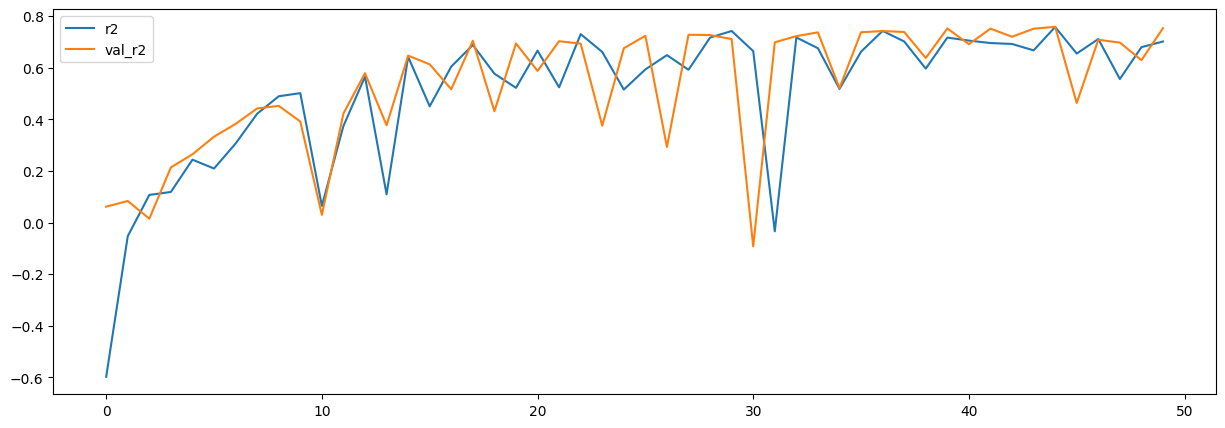

In [ ]:
# 결과시각화 (R^2 score)
plt.figure(figsize = (15,5))
plt.plot(model2.history.history['r2_score'], label = 'r2')
plt.plot(model2.history.history['val_r2_score'], label = 'val_r2')
plt.legend()
plt.show()

### 결과 정리
- 여러개의 컬럼을 추가로 학습했더니 비교적 성능이 개선된 걸 확인할 수 있음
- 결국 머신러닝을 사용하던 딥러닝을 사용하던 데이터의 질이나 양 등 데이터에 따라 성는이 차이가 나는 것을 확인할 수 있음
- 결국 인공지능 모델을 사용할 때 중요한 것 중 하나는 데이터를 어떻게 가공하는지가 중요하다.